# CM2_Project1 – Predicting Customer Churn with Deep Neural Networks

**Objective**

This project applyies a deep neural network to a real-world supervised classification dataset. The goal is not only to achieve predictive performance, but to analyze training dynamics (optimization, overfitting, and generalization). A baseline fully connected network is trained in TensorFlow, followed by a controlled experiment that changes exactly one training factor (dropout regularization) to compare learning behavior.


## Step 1 – Setup and Data Loading

In [ ]:
# Core libraries for data wrangling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Load Dataset
Upload the dataset file into Colab and load it into a DataFrame.

In [ ]:
# In Colab, upload the CSV file from your local machine
import google.colab.files as files
uploaded = files.upload()
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv', sep=',')

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (2).csv


## Step 2 – Exploratory Data Analysis (EDA)
Summarize dataset structure, data types, missing values, and basic statistics.

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**EDA Notes:** The Telco dataset contains a mix of numerical and categorical predictors. Neural networks require numeric inputs, so categorical features must be encoded. We also check for missing or non-numeric values that could affect training (e.g., `TotalCharges`).

## Step 3 – Data Preprocessing
Clean the data, encode categorical variables, split into features/target, and scale inputs for stable gradient updates.

In [ ]:
# Check for missing values before cleaning
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


No missing values

In [ ]:
# Remove non-predictive identifier column
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric (some rows may contain spaces); drop rows that become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)


### Encode Categorical Variables
One-hot encoding converts categorical columns into numeric indicator features for the neural network.

In [ ]:
# One-hot encode categorical variables (drop_first avoids redundant dummy columns)
df = pd.get_dummies(df, drop_first=True)

### Split Features and Target

In [ ]:
# Separate predictors (X) from the target label (y)
# Target: Churn_Yes (1 = churned, 0 = not churned)
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

### Train/Test Split
Hold out a test set to evaluate generalization to unseen data.

In [ ]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Feature Scaling
Standardization helps gradient descent converge more reliably by keeping features on a similar scale.

In [ ]:
# Fit the scaler on training data only to avoid data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 4 – Baseline Neural Network Model
Create and train a baseline fully connected network with at least two hidden layers.

In [ ]:
# Baseline architecture: two hidden layers for nonlinear feature learning
# Sigmoid output is used for binary classification
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile model: Adam optimizer + binary cross-entropy for churn classification
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"])

In [ ]:
# Train while monitoring validation performance to detect overfitting
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7029 - loss: 0.5294 - val_accuracy: 0.8000 - val_loss: 0.4194
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8091 - loss: 0.4173 - val_accuracy: 0.8160 - val_loss: 0.4114
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8176 - loss: 0.4103 - val_accuracy: 0.8080 - val_loss: 0.4077
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8178 - loss: 0.3987 - val_accuracy: 0.8071 - val_loss: 0.4106
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8093 - loss: 0.4089 - val_accuracy: 0.8142 - val_loss: 0.4044
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8178 - loss: 0.4001 - val_accuracy: 0.8178 - val_loss: 0.4036
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8242 - loss: 0.3837 - val_accuracy: 0.8098 - val_loss: 0.4135
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8267 - loss: 0.3808 - val_accuracy: 0.

### Baseline Evaluation
Evaluate the trained model on the held-out test set.

In [ ]:
# Test-set evaluation of baseline model
baseline_model.evaluate(X_test, y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7729 - loss: 0.4737


[0.5029239654541016, 0.7718549966812134]

## Step 5 – Training Experiment (Dropout Regularization)
To isolate the effect of regularization, we change exactly one training factor: add Dropout(0.3) after the first hidden layer.

In [ ]:
# Experimental architecture: same as baseline, but with Dropout regularization
# Dropout randomly disables neurons during training to reduce variance and improve generalization
exp_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")])

In [ ]:
# Compile and train the experimental model using the same optimizer and hyperparameters
exp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"])

exp_history = exp_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7215 - loss: 0.5283 - val_accuracy: 0.8053 - val_loss: 0.4151
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8042 - loss: 0.4329 - val_accuracy: 0.8036 - val_loss: 0.4084
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7954 - loss: 0.4193 - val_accuracy: 0.8107 - val_loss: 0.4052
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7925 - loss: 0.4252 - val_accuracy: 0.8107 - val_loss: 0.4033
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8048 - loss: 0.4342 - val_accuracy: 0.8080 - val_loss: 0.4046
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8039 - loss: 0.4200 - val_accuracy: 0.8071 - val_loss: 0.4042
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8090 - loss: 0.4130 - val_accuracy: 0.8142 - val_loss: 0.4021
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8199 - loss: 0.3998 - val_accuracy: 0.

### Experimental Evaluation
Evaluate the dropout model on the held-out test set.

In [ ]:
# Test-set evaluation of dropout model
exp_model.evaluate(X_test, y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7776 - loss: 0.4467


[0.4563305079936981, 0.783226728439331]

## Step 6 – Model Evaluation and Learning Curves
Plot training/validation curves to compare optimization behavior and overfitting between models.

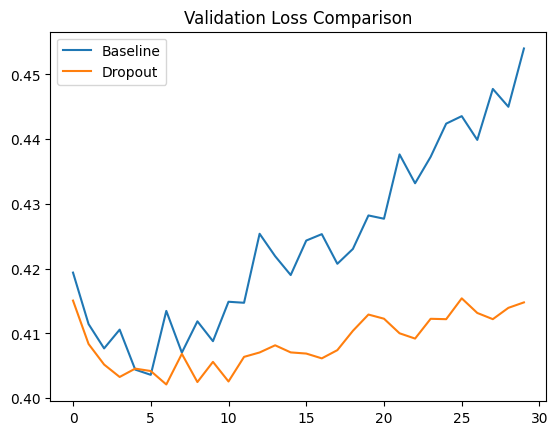

In [ ]:
plt.plot(baseline_history.history["val_loss"], label="Baseline")
plt.plot(exp_history.history["val_loss"], label="Dropout")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

Validation loss reflects generalization performance. A smoother or lower validation loss indicates the model is learning patterns that transfer to unseen data. If validation loss rises while training loss continues to fall, that is a strong sign of overfitting.

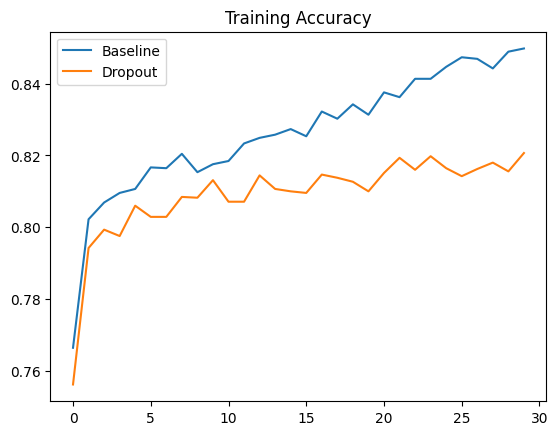

In [ ]:
plt.plot(baseline_history.history["accuracy"], label="Baseline")
plt.plot(exp_history.history["accuracy"], label="Dropout")
plt.legend()
plt.title("Training Accuracy")
plt.show()

Training accuracy measures fit on the training set. Regularization (dropout) often lowers training accuracy slightly, but can improve generalization by reducing memorization.

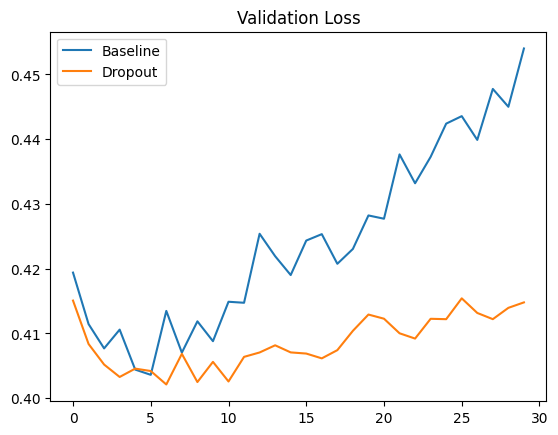

In [ ]:
plt.plot(baseline_history.history["val_loss"], label="Baseline")
plt.plot(exp_history.history["val_loss"], label="Dropout")
plt.legend()
plt.title("Validation Loss")
plt.show()

Comparing validation loss across models helps diagnose whether the training experiment improved stability. Reduced volatility and a smaller gap from training loss suggest better bias–variance balance.

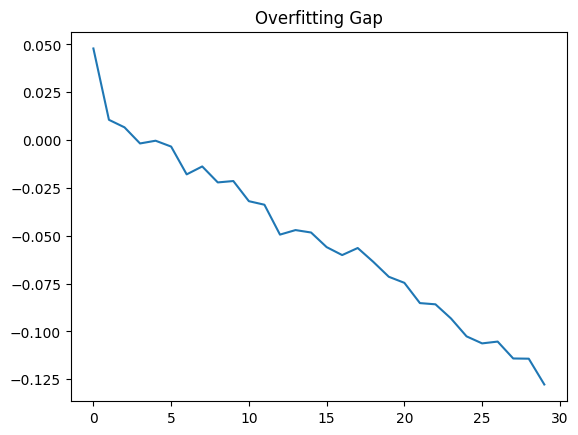

In [ ]:
gap = np.array(baseline_history.history["loss"]) - np.array(baseline_history.history["val_loss"])
plt.plot(gap)
plt.title("Overfitting Gap")
plt.show()

The overfitting gap approximates divergence between training and validation loss. A larger gap indicates higher variance and memorization; a smaller gap indicates improved generalization.

## Step 7 – Interpretation and Analysis

### Baseline Training Behavior
The baseline neural network converged as training loss decreased and training accuracy increased across epochs, indicating that gradient-based optimization successfully minimized the objective function. However, the validation loss curve showed weaker improvement relative to training performance, suggesting early overfitting. This pattern indicates the model began fitting training-specific noise or idiosyncrasies rather than learning fully generalizable representations.

### Effect of Dropout Regularization
The experimental model introduced dropout as a single controlled modification. Dropout randomly disables a proportion of neurons during training, which discourages co-adaptation and promotes more distributed feature learning. Compared with the baseline, the dropout model produced a more stable validation loss trajectory and reduced divergence between training and validation metrics. Although training accuracy may be slightly lower due to the regularization constraint, the validation behavior suggests improved generalization.

### Connecting Results to Core Concepts
This experiment demonstrates that optimization success (high training accuracy, low training loss) does not guarantee generalization. Validation metrics are therefore essential for diagnosing overfitting. Regularization techniques such as dropout reduce effective model capacity during training, lowering variance and improving the bias-variance trade-off. Because the experiment changed only one factor, performance differences can be interpreted causally as the effect of dropout on training dynamics.

## Conclusion
This project demonstrated an end-to-end deep learning workflow for a real-world tabular classification task. The baseline model learned meaningful churn-related patterns but exhibited signs of overfitting when evaluated on validation metrics. Introducing dropout as a single training modification improved generalization by stabilizing learning and reducing variance-driven divergence between training and validation performance. Overall, the results reinforce training principles: model capacity must be balanced with regularization, and learning curves are critical for interpreting optimization behavior beyond accuracy alone.
